In [2]:
import pandas as pd 
import numpy as np 
from pathlib import Path
from src.data.functions import json_to_dict
from src.models.time_varying_ss import TimeVaryingStateSpace
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

In [3]:
top_dir = Path().absolute()
PARENT_FILE_PATH = top_dir / "models" / "2026-03-03 B7H4 SAM 1000L Partition Model"
model_config = json_to_dict(Path(PARENT_FILE_PATH, "B7H4_model_parameters.json"))

a_matrices = np.array(model_config["a_matrix"])
b_matrices = np.array(model_config["b_matrix"])

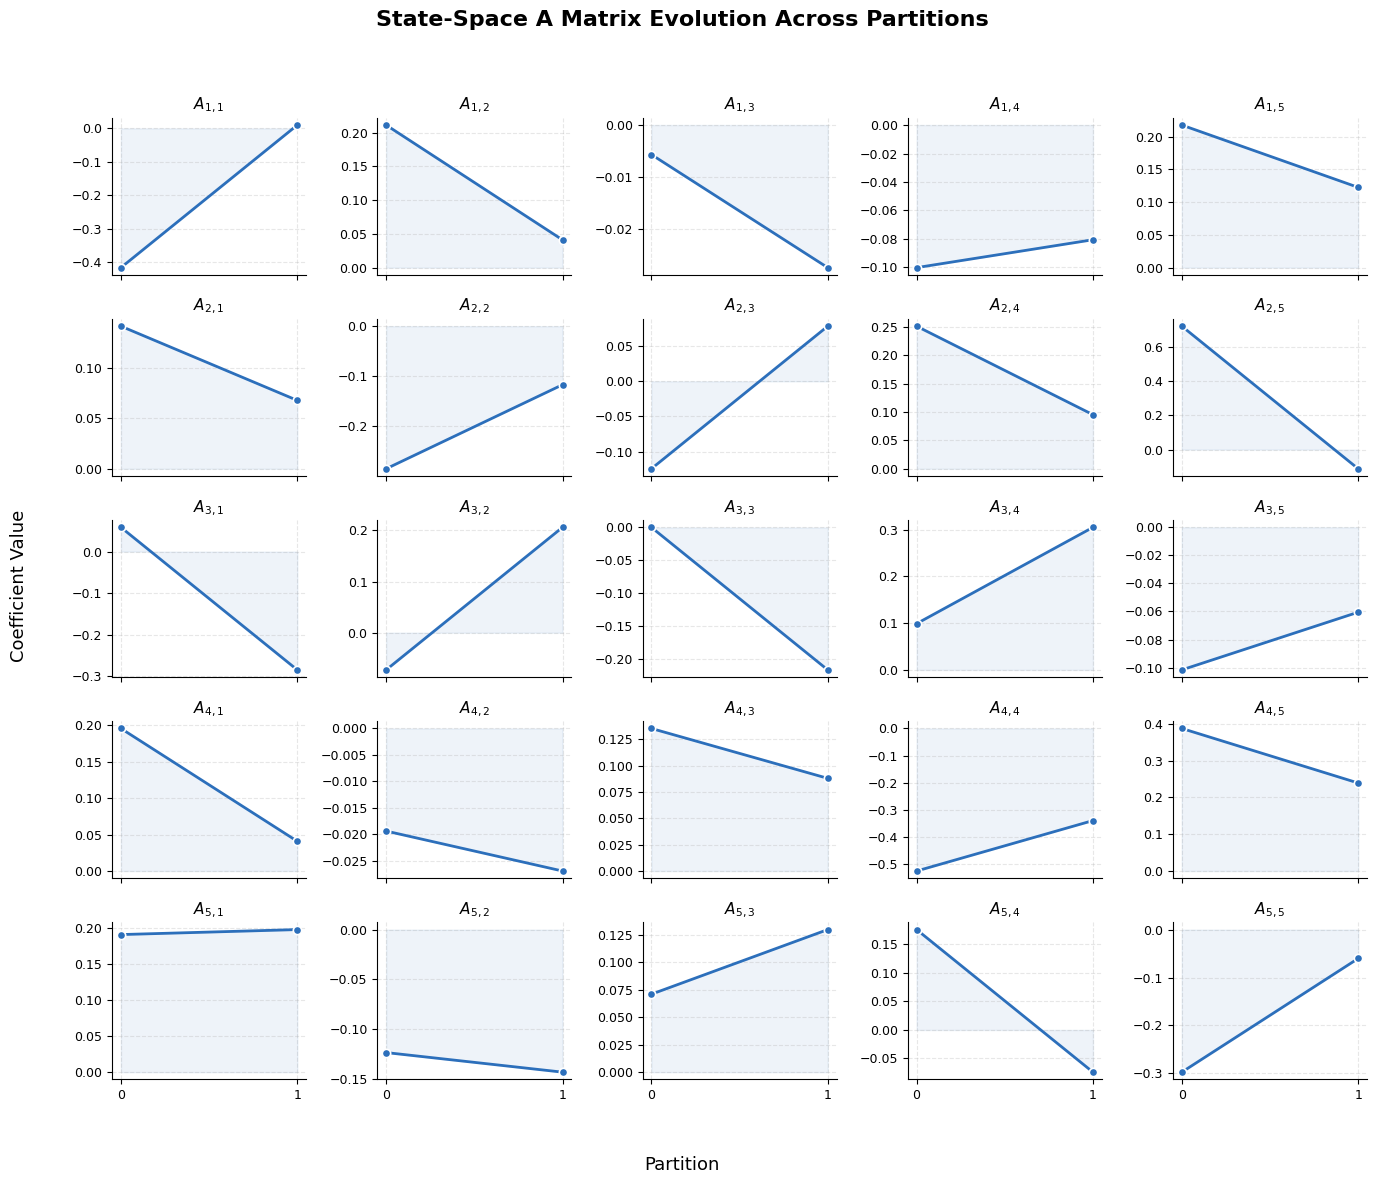

In [4]:
fig, axes = plt.subplots(5, 5, figsize=(14, 12), sharex=True)
fig.suptitle("State-Space A Matrix Evolution Across Partitions", 
             fontsize=16, fontweight="bold", y=0.98)

partitions = np.arange(a_matrices.shape[0])  # [0, 1, 2]

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        y = a_matrices[:, i, j]

        ax.plot(partitions, y, "o-", color="#2c6fbb", markersize=6, 
                linewidth=2, markeredgecolor="white", markeredgewidth=1.2)
        ax.fill_between(partitions, y, alpha=0.08, color="#2c6fbb")

        ax.set_title(f"$A_{{{i+1},{j+1}}}$", fontsize=11)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

# shared axis labels
fig.supxlabel("Partition", fontsize=13)
fig.supylabel("Coefficient Value", fontsize=13)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

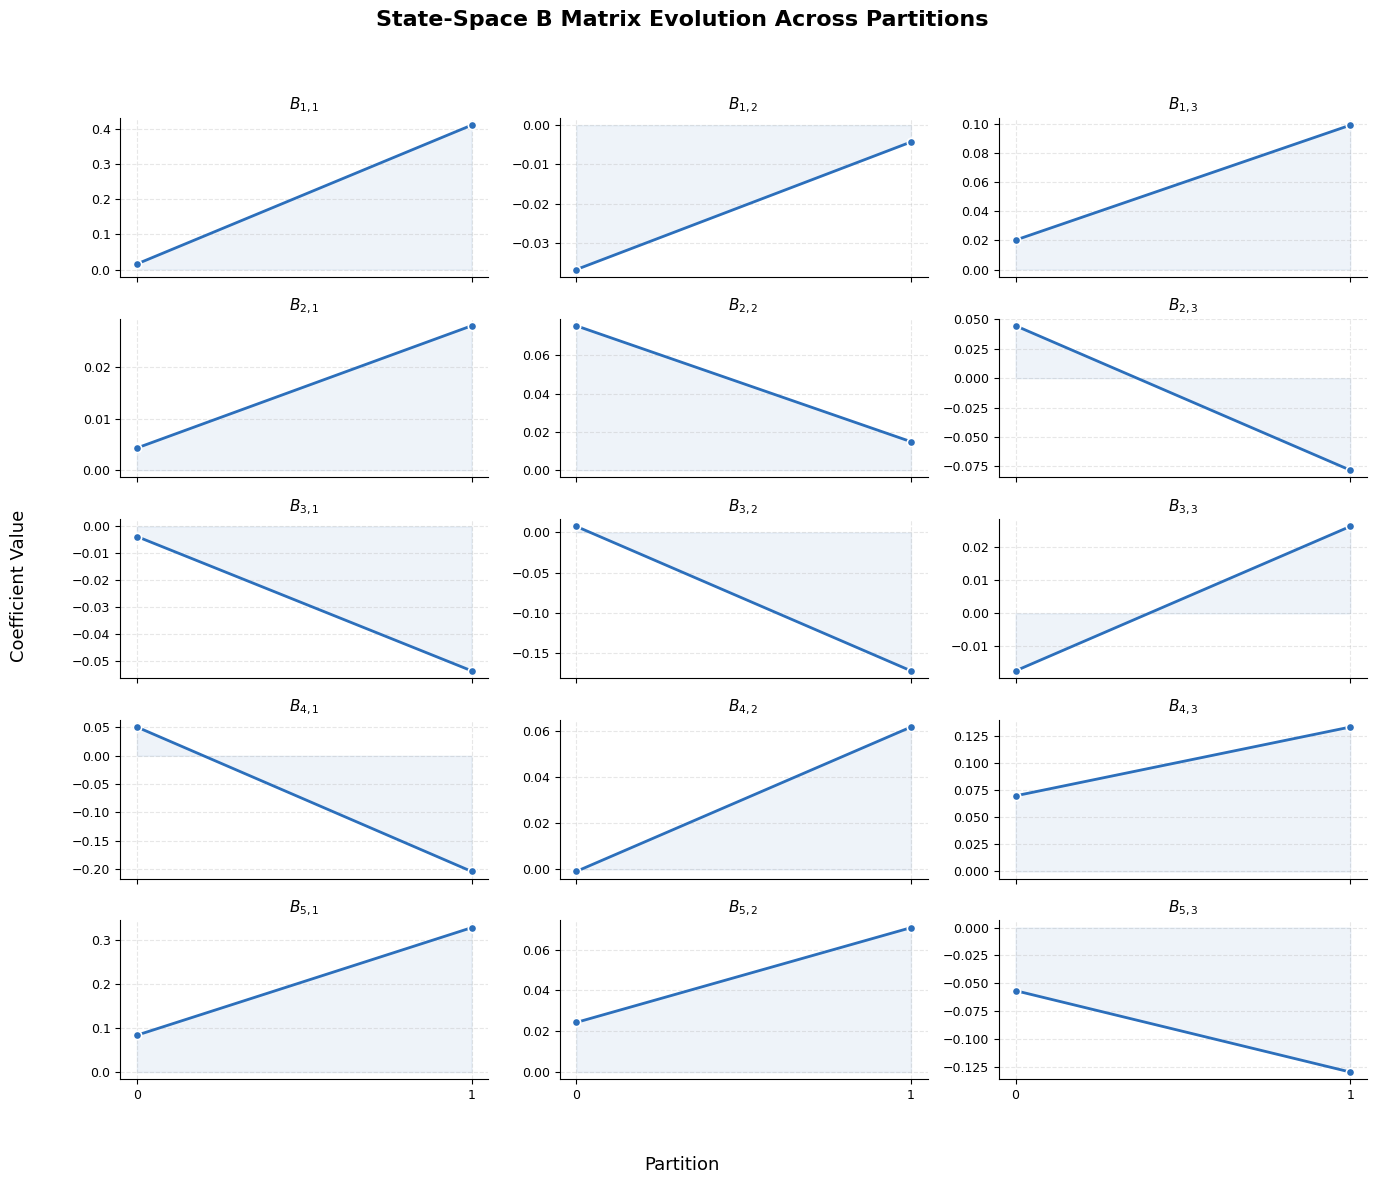

In [5]:
fig, axes = plt.subplots(5, 3, figsize=(14, 12), sharex=True)
fig.suptitle("State-Space B Matrix Evolution Across Partitions", 
             fontsize=16, fontweight="bold", y=0.98)

partitions = np.arange(b_matrices.shape[0])  # [0, 1, 2]

for i in range(5):
    for j in range(3):
        ax = axes[i, j]
        y = b_matrices[:, i, j]

        ax.plot(partitions, y, "o-", color="#2c6fbb", markersize=6, 
                linewidth=2, markeredgecolor="white", markeredgewidth=1.2)
        ax.fill_between(partitions, y, alpha=0.08, color="#2c6fbb")

        ax.set_title(f"$B_{{{i+1},{j+1}}}$", fontsize=11)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

# shared axis labels
fig.supxlabel("Partition", fontsize=13)
fig.supylabel("Coefficient Value", fontsize=13)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

### Cubic Interpolation of Components

In [6]:
# --- Synthetic example: 4 states, 2 inputs, 3 partitions ---
np.random.seed(42)
top_dir = Path().absolute()
PARENT_FILE_PATH = top_dir / "models" / "2026-03-03 B7H4 SAM 1000L Partition Model"
model_config = json_to_dict(Path(PARENT_FILE_PATH, "B7H4_model_parameters.json"))

a_matrices = np.array(model_config["a_matrix"])
b_matrices = np.array(model_config["b_matrix"])

n_states, n_inputs, n_partitions = 6, 4, 3
t_partitions = np.array(model_config["Partitions"]["time_partitions"])  # e.g., batch days

# a_matrices = np.random.randn(n_partitions, n_states, n_states) * 0.5
# b_matrices = np.random.randn(n_partitions, n_states, n_inputs) * 0.3
a1 = 2.0
a2 = 8.0
b1 = 3.0
b2 = 7.0

# 1) Create model
model = TimeVaryingStateSpace(t_partitions, a_matrices, b_matrices)
a_models = []
b_models = []
x = np.linspace(0, 14, 14)
for step in x:
    a, b = model.get_AB(step)
    a_models.append(a)
    b_models.append(b)

print(model)
print(f"\nA at day {a1}:\n{model.get_A(a1)}")
print(f"\nA at day {a2}:\n{model.get_A(a2)}")
print(f"\nB at day {b1}:\n{model.get_B(b1)}")
print(f"\nB at day {b2}:\n{model.get_B(b2)}")

TimeVaryingStateSpace(states=5, inputs=3, partitions=2, t_range=[0.0, 15.0])

A at day 2.0:
[[-0.34127901  0.18136225 -0.00947763 -0.0967735   0.20098153]
 [ 0.1287856  -0.25595788 -0.0887805   0.22354072  0.57422315]
 [-0.00178228 -0.02383646 -0.03790652  0.13502116 -0.09443966]
 [ 0.16819106 -0.02070354  0.12696868 -0.49349981  0.36124139]
 [ 0.19181727 -0.12687431  0.08123492  0.13218884 -0.25580895]]

A at day 8.0:
[[ 0.00388206  0.04349332 -0.02709912 -0.08087972  0.12385918]
 [ 0.06899485 -0.11956973  0.0755812   0.09732856 -0.10023482]
 [-0.27958427  0.20227297 -0.21391454  0.30203796 -0.06109078]
 [ 0.04291447 -0.02682275  0.08859797 -0.34256553  0.24111308]
 [ 0.19742631 -0.14279924  0.128904   -0.07050408 -0.06358343]]

B at day 3.0:
[[ 0.15485035 -0.02529227  0.04796857]
 [ 0.0126645   0.05419123  0.00136662]
 [-0.02124701 -0.05583759 -0.00200864]
 [-0.03893839  0.02109626  0.09190374]
 [ 0.16942061  0.04064593 -0.08236139]]

B at day 7.0:
[[ 0.40548466 -0.00469777  0.098022

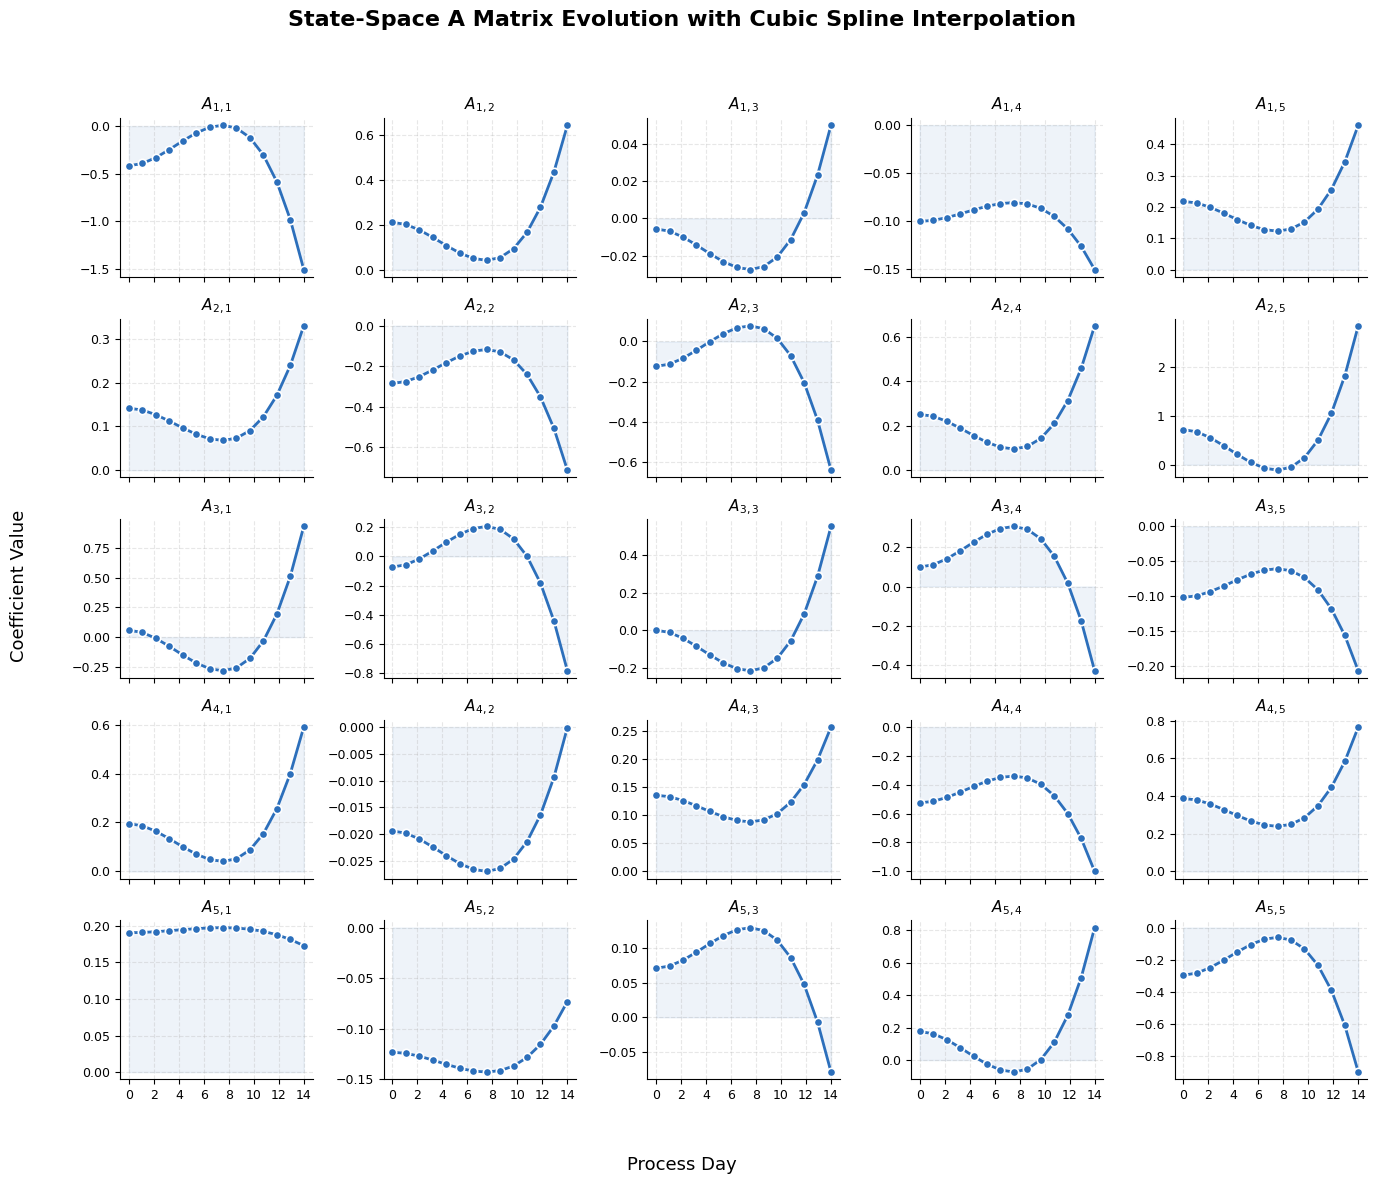

In [7]:
fig, axes = plt.subplots(5, 5, figsize=(14, 12), sharex=True)
fig.suptitle("State-Space A Matrix Evolution with Cubic Spline Interpolation", 
             fontsize=16, fontweight="bold", y=0.98)

a_model_matrix = np.array(a_models)
partitions = np.linspace(0, 14, 14)  # [0, 1, 2]

for i in range(5):
    for j in range(5):
        ax = axes[i, j]
        y = a_model_matrix[:, i, j]

        ax.plot(partitions, y, "o-", color="#2c6fbb", markersize=6, 
                linewidth=2, markeredgecolor="white", markeredgewidth=1.2)
        ax.fill_between(partitions, y, alpha=0.08, color="#2c6fbb")

        ax.set_title(f"$A_{{{i+1},{j+1}}}$", fontsize=11)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

# shared axis labels
fig.supxlabel("Process Day", fontsize=13)
fig.supylabel("Coefficient Value", fontsize=13)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

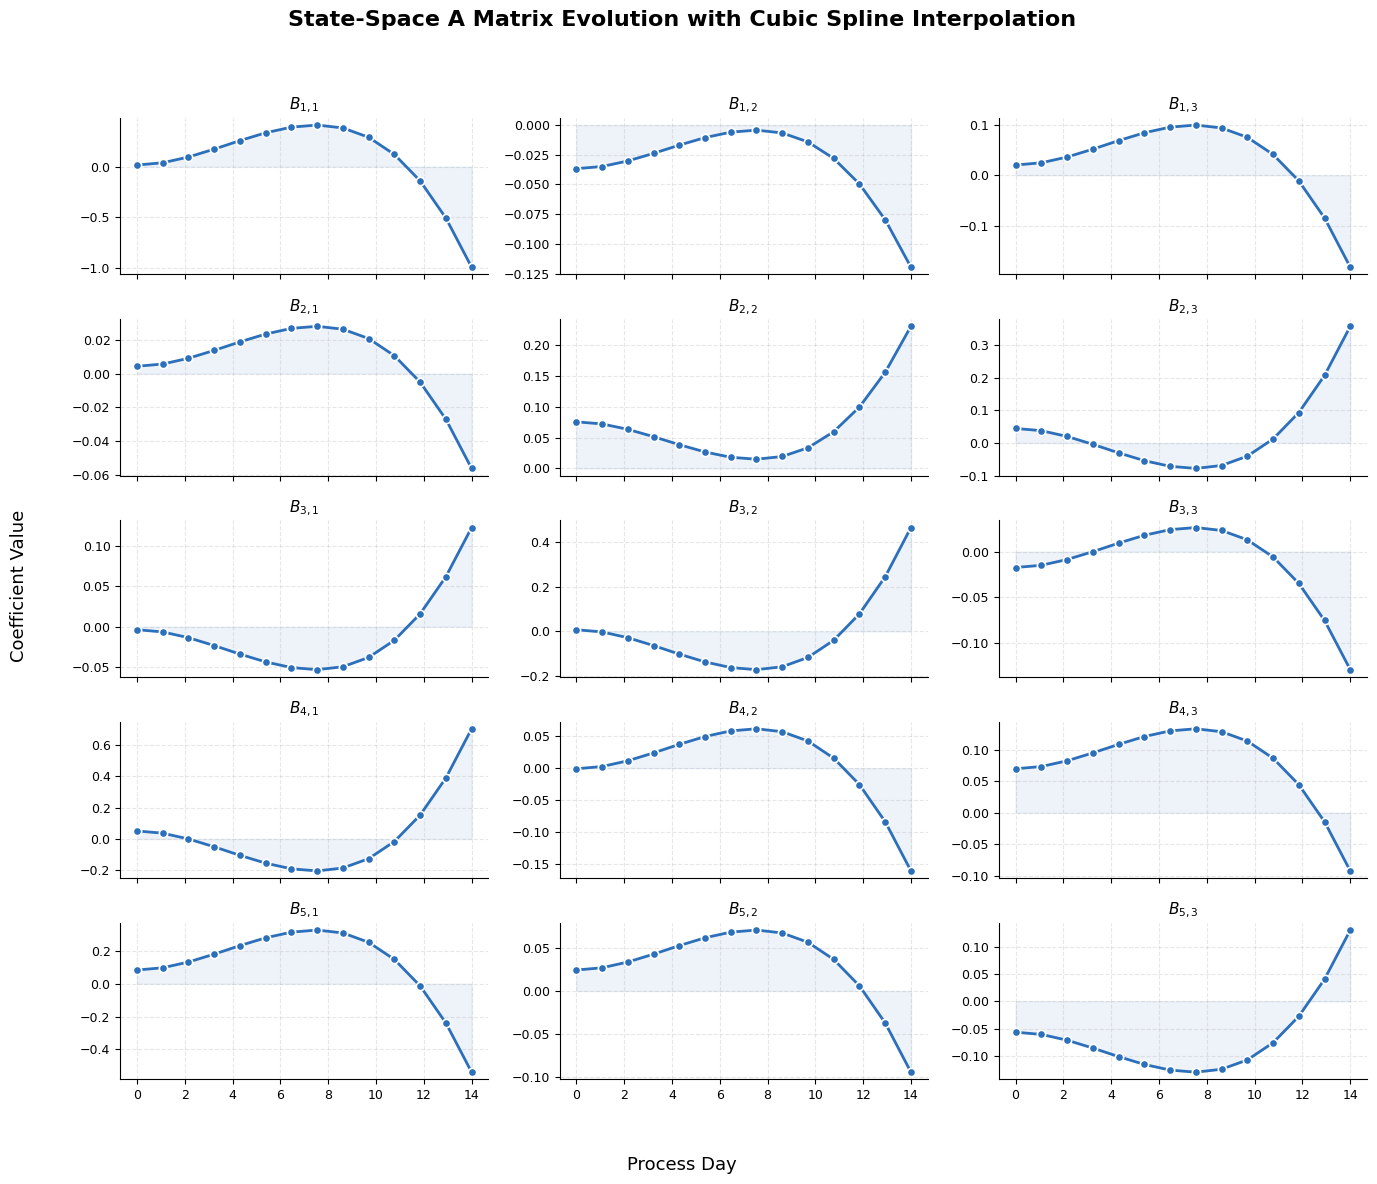

In [8]:
fig, axes = plt.subplots(5, 3, figsize=(14, 12), sharex=True)
fig.suptitle("State-Space B Matrix Evolution with Cubic Spline Interpolation", 
             fontsize=16, fontweight="bold", y=0.98)

b_model_matrix = np.array(b_models)
partitions = np.linspace(0, 14, 14)  # [0, 1, 2]

for i in range(5):
    for j in range(3):
        ax = axes[i, j]
        y = b_model_matrix[:, i, j]

        ax.plot(partitions, y, "o-", color="#2c6fbb", markersize=6, 
                linewidth=2, markeredgecolor="white", markeredgewidth=1.2)
        ax.fill_between(partitions, y, alpha=0.08, color="#2c6fbb")

        ax.set_title(f"$B_{{{i+1},{j+1}}}$", fontsize=11)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.tick_params(labelsize=9)
        ax.grid(True, alpha=0.3, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)

# shared axis labels
fig.supxlabel("Process Day", fontsize=13)
fig.supylabel("Coefficient Value", fontsize=13)
fig.tight_layout(rect=[0.03, 0.03, 1, 0.95])
plt.show()

In [9]:
time = np.linspace(0,12, 100)
time

array([ 0.        ,  0.12121212,  0.24242424,  0.36363636,  0.48484848,
        0.60606061,  0.72727273,  0.84848485,  0.96969697,  1.09090909,
        1.21212121,  1.33333333,  1.45454545,  1.57575758,  1.6969697 ,
        1.81818182,  1.93939394,  2.06060606,  2.18181818,  2.3030303 ,
        2.42424242,  2.54545455,  2.66666667,  2.78787879,  2.90909091,
        3.03030303,  3.15151515,  3.27272727,  3.39393939,  3.51515152,
        3.63636364,  3.75757576,  3.87878788,  4.        ,  4.12121212,
        4.24242424,  4.36363636,  4.48484848,  4.60606061,  4.72727273,
        4.84848485,  4.96969697,  5.09090909,  5.21212121,  5.33333333,
        5.45454545,  5.57575758,  5.6969697 ,  5.81818182,  5.93939394,
        6.06060606,  6.18181818,  6.3030303 ,  6.42424242,  6.54545455,
        6.66666667,  6.78787879,  6.90909091,  7.03030303,  7.15151515,
        7.27272727,  7.39393939,  7.51515152,  7.63636364,  7.75757576,
        7.87878788,  8.        ,  8.12121212,  8.24242424,  8.36

In [10]:
np.where(time == time[24])[0][0]

np.int64(24)